In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import os
from scipy.interpolate import interp1d
import time
from scipy.ndimage import distance_transform_edt, map_coordinates


Map data loaded successfully.
Grid map shape: (585, 514)
Number of raceline points: 203


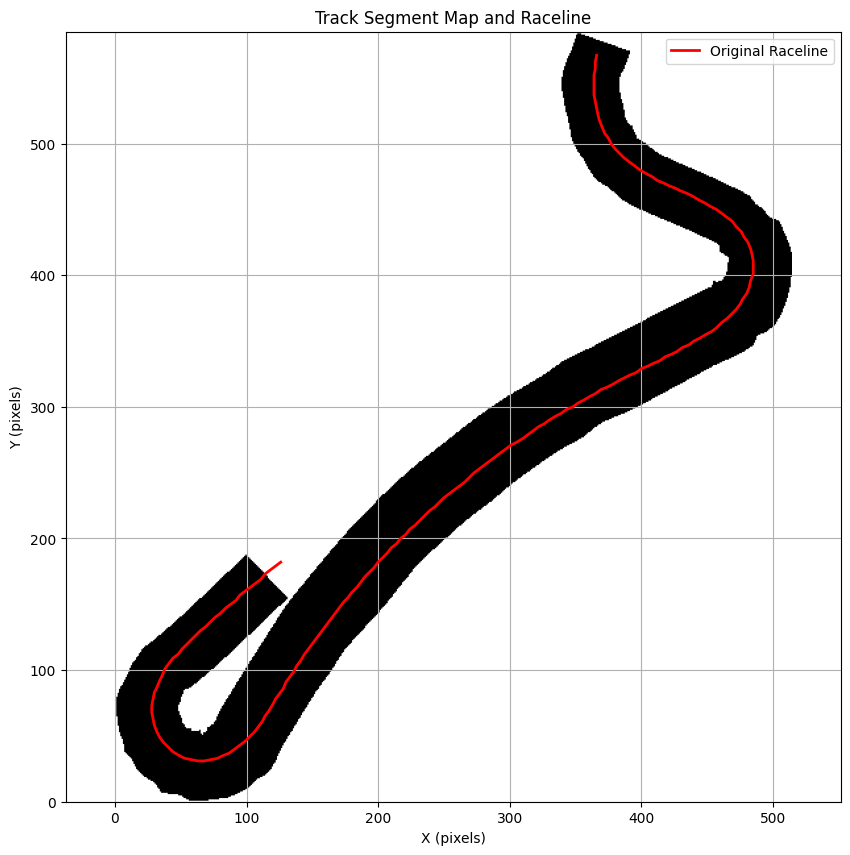

In [3]:
# Load Map Data from the .npz file
map_path = 'nuerburgring_segment_map.npz'

if not os.path.exists(map_path):
    print(f"Map file not found at '{map_path}'")
    print("Please run 'research/UniCon/create_track_map.py' first to generate the map file.")
    # As a fallback for the rest of the notebook, create dummy data.
    grid_map = np.zeros((100, 100))
    raceline_grid = np.array([np.linspace(10, 90, 100), np.linspace(10, 90, 100)]).T
    resolution = 1.0
    translation_offset = np.array([0, 0])
    print("Using dummy data to proceed.")
else:
    map_data = np.load(map_path)
    grid_map = map_data['grid_map']
    raceline_grid = map_data['raceline_grid']
    resolution = map_data['resolution']
    translation_offset = map_data['translation_offset']
    print("Map data loaded successfully.")

print(f"Grid map shape: {grid_map.shape}")
print(f"Number of raceline points: {len(raceline_grid)}")

# Visualize the map and the original raceline
plt.figure(figsize=(10, 10))
plt.imshow(grid_map, cmap='gray', origin='lower', extent=[0, grid_map.shape[1], 0, grid_map.shape[0]])
plt.plot(raceline_grid[:, 0], raceline_grid[:, 1], 'r-', linewidth=2, label='Original Raceline')
plt.title('Track Segment Map and Raceline')
plt.xlabel('X (pixels)')
plt.ylabel('Y (pixels)')
plt.legend()
plt.axis('equal')
plt.grid(True)
plt.show()


In [4]:
# --- Kinematic bicycle (pixel units; resolution = pixels/m) ---
def simulate_vehicle_bc(x0, u_seq, dt, state_steps, L_pix=2.7, v_max=None, delta_rate_max=None):
    """
    x = [x, y, theta, v]; u = [a, delta]
    theta_dot = v / L * tan(delta)
    """
    control_steps = u_seq.shape[0]
    states = np.zeros((state_steps, 4))
    states[0] = x0[:4]  # Ignore original r

    last_delta = 0.0
    for k in range(control_steps):
        x, y, theta, v = states[k]
        a, delta = u_seq[k]

        # Limit steering rate change (optional, for better convergence)
        if delta_rate_max is not None:
            delta = np.clip(delta, last_delta - delta_rate_max * dt, last_delta + delta_rate_max * dt)
        last_delta = delta

        v_next = v + dt * a
        if v_max is not None:
            v_next = np.clip(v_next, 0.0, v_max)

        theta_dot = v_next / L_pix * np.tan(delta)
        theta_next = theta + dt * theta_dot

        x_next = x + dt * v_next * np.cos(theta)
        y_next = y + dt * v_next * np.sin(theta)

        states[k+1] = [x_next, y_next, theta_next, v_next]

    return states

# Reparameterize control variables using tanh to avoid boundary issues
def unpack_controls(z_flat, control_steps, a_max, delta_max):
    z = z_flat.reshape(control_steps, 2)
    a = a_max * np.tanh(z[:, 0])
    delta = delta_max * np.tanh(z[:, 1])
    return np.column_stack([a, delta])

def build_sdf_from_grid(grid):
    g = grid.astype(np.float32)
    g = (g - g.min()) / (g.max() - g.min() + 1e-8)   # Normalize to [0,1]
    # Track is "black" -> small values; auto-threshold at 0.5 is robust
    inside_mask = g < 0.5
    # Positive distance inside, negative outside
    d_in  = distance_transform_edt(inside_mask)
    d_out = distance_transform_edt(~inside_mask)
    sdf = d_in - d_out
    return sdf, inside_mask

def sample_sdf_bilinear(sdf, xy):
    # xy: [N,2] with columns [x,y] in pixel coordinates
    # map_coordinates requires order [row(y), col(x)]
    coords = np.vstack([xy[:,1], xy[:,0]])
    return map_coordinates(sdf, coords, order=1, mode='nearest')


In [5]:
# Setup of Parameters and Reference Trajectory

# Define the horizon for the optimal control problem
state_steps = 101
control_steps = state_steps - 1

# Calculate the geometric length of the raceline in pixels
path_length_pixels = np.sum(np.linalg.norm(np.diff(raceline_grid, axis=0), axis=1))
print(f"Total raceline length: {path_length_pixels:.2f} pixels.")
if resolution > 0:
    print(f"Assuming {resolution:.2f} pixels/meter, the length is approx {path_length_pixels/resolution:.2f} meters.")

# --- Adjust vehicle dynamics parameters based on the track ---
dt = 0.2  # Time step in seconds
total_time = control_steps * dt
# Required average speed to cover the distance in the given time
avg_speed_pixels = path_length_pixels / total_time
print(f"To finish in {total_time}s, target average speed: {avg_speed_pixels:.2f} pixels/s.")

# Set dynamic constraints based on the required speed (HIGHLY RELAXED CONSTRAINTS)
v_target = avg_speed_pixels * 2.0  # Further increased target speed factor
a_max = 35.0  # pixels/s^2, much higher acceleration capability
delta_max = 1.0  # rad, allows for very sharp turns (~57 degrees)

print("\nSetting dynamic parameters (HIGHLY RELAXED):")
print(f"  dt = {dt}s")
print(f"  Control Steps = {control_steps}")
print(f"  Max Acceleration (a_max) = {a_max:.2f} pixels/s^2")
print(f"  Max Steering (delta_max) = {delta_max:.2f} rad ({delta_max*180/np.pi:.1f} degrees)")

# --- Create the reference trajectory ---
# The solver needs a target point for each time step. We resample the original raceline.
arc_length = np.concatenate(([0], np.cumsum(np.linalg.norm(np.diff(raceline_grid, axis=0), axis=1))))
f_x = interp1d(arc_length, raceline_grid[:, 0], kind='cubic')
f_y = interp1d(arc_length, raceline_grid[:, 1], kind='cubic')
target_arc_length = np.linspace(0, arc_length[-1], state_steps)
raceline_ref = np.vstack([f_x(target_arc_length), f_y(target_arc_length)]).T

# --- Define Initial State (4D for bicycle model) ---
x0_pos = raceline_ref[0]
dx = raceline_ref[1, 0] - raceline_ref[0, 0]
dy = raceline_ref[1, 1] - raceline_ref[0, 1]
theta0 = np.arctan2(dy, dx)
x0 = np.array([x0_pos[0], x0_pos[1], theta0, 0.0]) # [x, y, theta, v]

print(f"\nInitial state (x0): {np.round(x0, 2)}")

# --- Additional References for the new Cost Function ---
# Reference heading for terminal constraint
dxy = np.diff(raceline_ref, axis=0, append=raceline_ref[-1:])
theta_ref = np.arctan2(dxy[:,1], dxy[:,0])

# Reference velocity profile to track (HIGHLY RELAXED)
v_max = 3.5 * avg_speed_pixels # Much higher maximum velocity
v_ref = np.clip(np.linspace(0, 2.0*avg_speed_pixels, state_steps), 0, v_max)

# --- Build Signed Distance Field (SDF) for track constraints ---
sdf_map, track_mask = build_sdf_from_grid(grid_map)
# Set safety margin in pixels. 8-12 pixels is a conservative choice.
safety_margin_pix = 10.0
w_safety = 40.0   # Weight for the safety constraint

# Optional: Visualize the SDF
# plt.figure(figsize=(10,10)); plt.imshow(sdf_map, origin='lower'); plt.colorbar(); plt.title('Signed Distance Field'); plt.show()


Total raceline length: 1012.59 pixels.
Assuming 1.00 pixels/meter, the length is approx 1012.59 meters.
To finish in 20.0s, target average speed: 50.63 pixels/s.

Setting dynamic parameters (HIGHLY RELAXED):
  dt = 0.2s
  Control Steps = 100
  Max Acceleration (a_max) = 35.00 pixels/s^2
  Max Steering (delta_max) = 1.00 rad (57.3 degrees)

Initial state (x0): [366.   567.    -1.67   0.  ]


In [6]:
# Optimal Control Cost Function (Reparameterized)
def cost_function_reparam(z_flat, x0, raceline_ref, theta_ref, v_ref, dt,
                          state_steps, control_steps, a_max, delta_max,
                          L_pix=2.7, v_max=None,
                          sdf_map=None, safety_margin_pix=8.0, w_safety=40.0):
    u_seq = unpack_controls(z_flat, control_steps, a_max, delta_max)
    states = simulate_vehicle_bc(x0, u_seq, dt, state_steps, L_pix=L_pix, v_max=v_max, delta_rate_max=2.5)  # Much higher steering rate

    # Weights
    w_path = 5.0
    w_u = 1e-3
    w_smooth = 0.05
    w_v = 0.02
    w_terminal = 30.0

    # 1) Path tracking error
    pos_err = states[:, :2] - raceline_ref
    J_path = np.sum(np.einsum('ij,ij->i', pos_err, pos_err))

    # 2) Control effort + smoothness
    J_u = np.sum(u_seq**2)
    du = np.diff(u_seq, axis=0)
    J_smooth = np.sum(du**2)

    # 3) Velocity reference tracking
    J_v = np.sum((states[:, 3] - v_ref)**2)

    # 4) Terminal position/heading
    term_pos = np.sum((states[-1, :2] - raceline_ref[-1])**2)
    dtheta = (states[-1, 2] - theta_ref[-1] + np.pi) % (2*np.pi) - np.pi
    J_term = term_pos + 0.1 * dtheta**2

    # 5) Safety constraint using an inverse barrier function
    J_safe = 0.0
    if sdf_map is not None:
        sdf_vals = sample_sdf_bilinear(sdf_map, states[:, :2])
        clear = sdf_vals - safety_margin_pix # Clearance > 0 is safe
        eps = 1.0 # Minimum clearance (pixels) to avoid divergence
        phi = 1.0 / np.maximum(clear, eps)**2 # Inverse barrier (approx. 1/clear^2)
        J_safe = np.sum(phi)


    J = (w_path*J_path + w_u*J_u + w_smooth*J_smooth +
         w_v*J_v + w_terminal*J_term + w_safety*J_safe)
    return float(J)


In [7]:
# Solve with Inverse Barrier and Continuation Method

# --- Optimizer Setup ---
num_decision_vars = control_steps * 2
z0 = np.zeros(num_decision_vars) # Initial guess for z is zero

print("Solving with inverse barrier and continuation method...")
start_time = time.time()

# --- Run the Optimizer with Continuation ---
# This loop gradually increases the safety weight to find a robust solution.
#w_safety_schedule = [10.0, 50.0, 200.0, 800.0]
w_safety_schedule = [100.0, 800.0, 3200.0, 12800.0, 51200.0]

for i, w_safety_current in enumerate(w_safety_schedule):
    print(f"\n--- Continuation Step {i+1}/{len(w_safety_schedule)}: w_safety = {w_safety_current} ---")
    res = minimize(
        cost_function_reparam,
        z0,
        args=(x0, raceline_ref, theta_ref, v_ref, dt, state_steps, control_steps, a_max, delta_max, 2.7*resolution, v_max,
              sdf_map, safety_margin_pix, w_safety_current),
        method="L-BFGS-B",
        options={"maxiter": 400, "maxfun": 200000, "ftol": 1e-6, "gtol": 1e-5, "maxls": 50, "disp": True}
    )
    z0 = res.x  # Warm start for the next iteration

end_time = time.time()
print(f"\nTotal optimization finished in {end_time - start_time:.2f} seconds.")

if res.success:
    print("Optimization succeeded.")
    u_optimal = unpack_controls(res.x, control_steps, a_max, delta_max)
    states_optimal = simulate_vehicle_bc(x0, u_optimal, dt, state_steps, L_pix=2.7*resolution, v_max=v_max)
else:
    print("Optimization message:", res.message)
    u_optimal = unpack_controls(res.x, control_steps, a_max, delta_max)
    states_optimal = simulate_vehicle_bc(x0, u_optimal, dt, state_steps, L_pix=2.7*resolution, v_max=v_max)


Solving with inverse barrier and continuation method...

--- Continuation Step 1/5: w_safety = 100.0 ---

--- Continuation Step 2/5: w_safety = 800.0 ---

--- Continuation Step 3/5: w_safety = 3200.0 ---

--- Continuation Step 4/5: w_safety = 12800.0 ---

--- Continuation Step 5/5: w_safety = 51200.0 ---

Total optimization finished in 265.53 seconds.
Optimization succeeded.


Plotting results from the successful optimization...


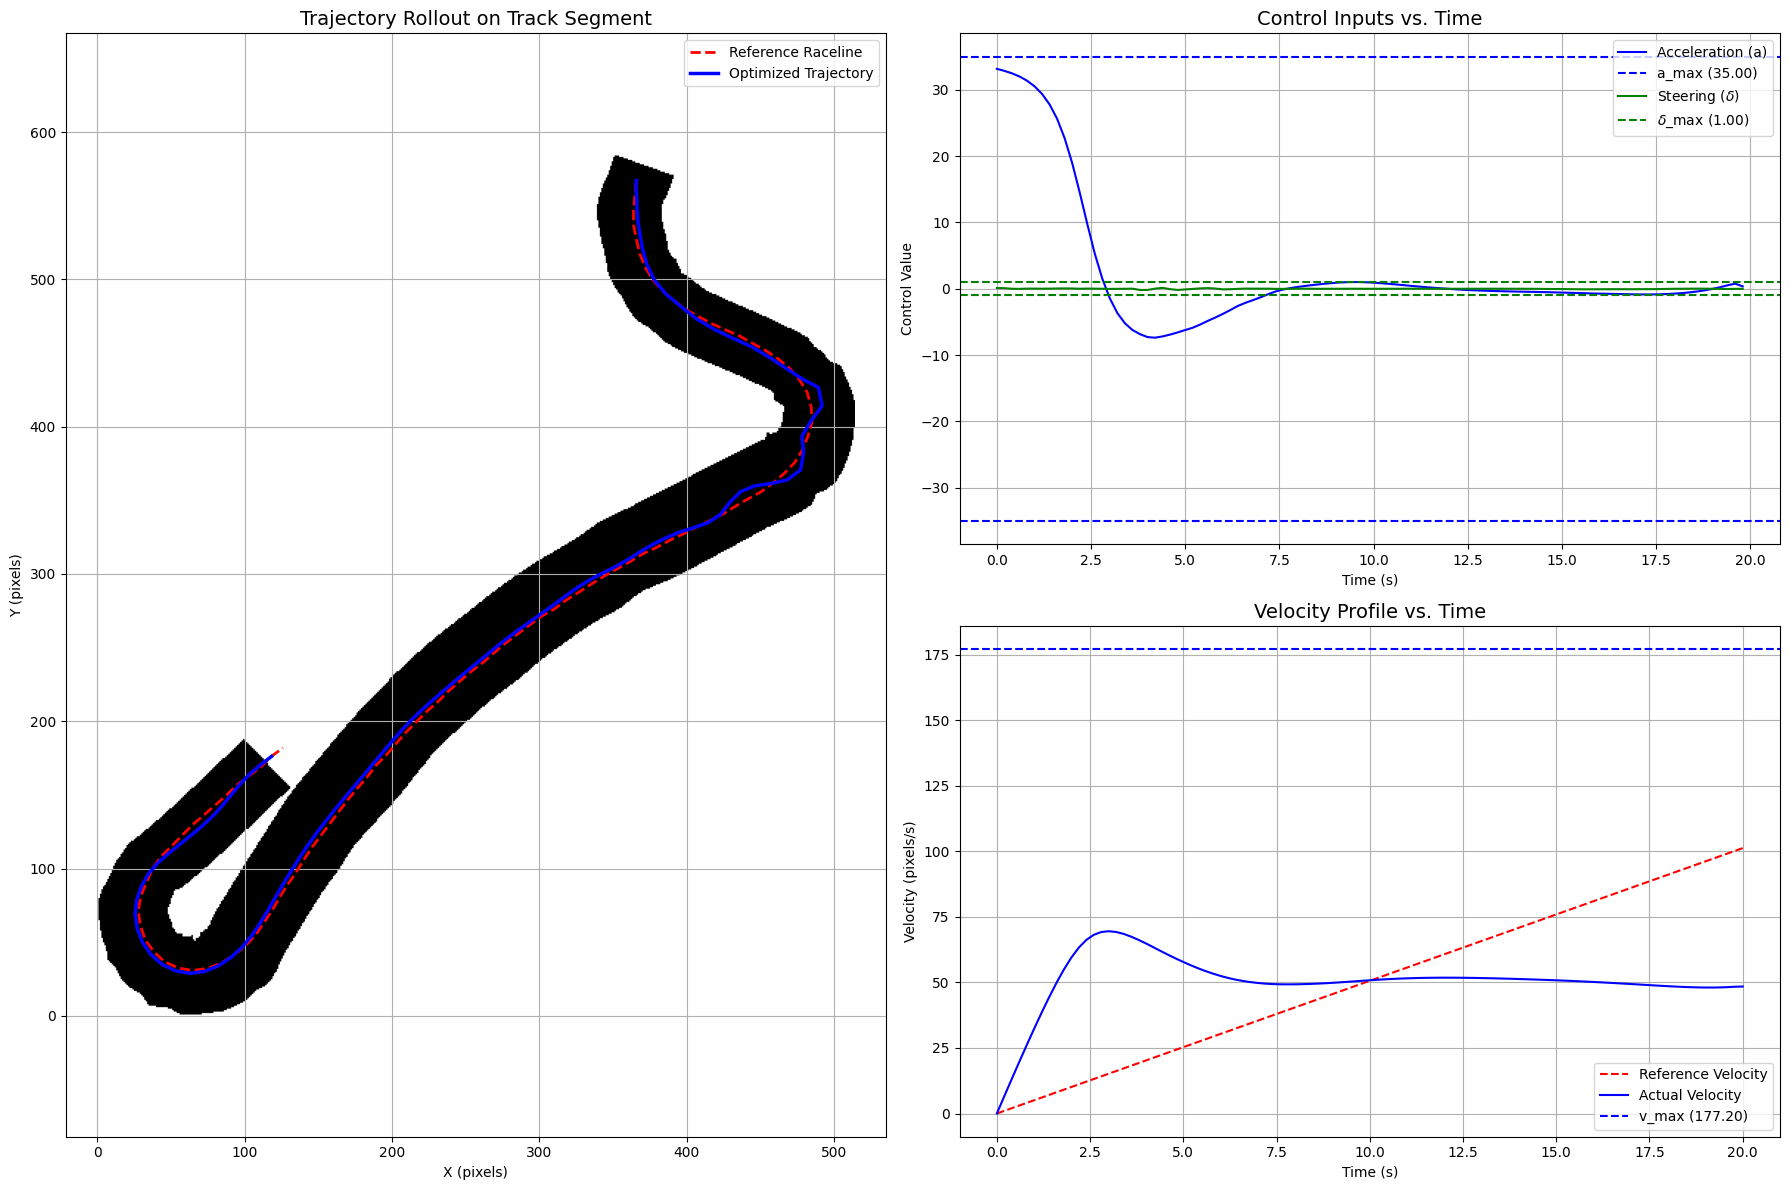

In [8]:
# --- Visualization of the Results ---
# This cell plots the optimized trajectory, control inputs, and velocity profile.

def plot_results(states, u_seq, raceline_ref, v_ref, grid_map, dt, control_steps, a_max, delta_max):
    t_arr_states = np.arange(states.shape[0]) * dt
    t_arr_controls = np.arange(u_seq.shape[0]) * dt

    fig = plt.figure(figsize=(18, 12))
    gs = fig.add_gridspec(2, 2)

    # 1) Trajectory on the map (larger plot)
    ax1 = fig.add_subplot(gs[:, 0])
    ax1.imshow(grid_map, cmap='gray', origin='lower', extent=[0, grid_map.shape[1], 0, grid_map.shape[0]])
    ax1.plot(raceline_ref[:, 0], raceline_ref[:, 1], 'r--', linewidth=2, label='Reference Raceline')
    ax1.plot(states[:, 0], states[:, 1], 'b-', linewidth=2.5, label='Optimized Trajectory')
    ax1.set_title('Trajectory Rollout on Track Segment', fontsize=14)
    ax1.set_xlabel('X (pixels)')
    ax1.set_ylabel('Y (pixels)')
    ax1.legend()
    ax1.axis('equal')
    ax1.grid(True)

    # 2) Control inputs
    ax2 = fig.add_subplot(gs[0, 1])
    ax2.plot(t_arr_controls, u_seq[:, 0], 'b-', label=f'Acceleration (a)')
    ax2.axhline(y=a_max, color='b', linestyle='--', label=f'a_max ({a_max:.2f})')
    ax2.axhline(y=-a_max, color='b', linestyle='--')
    ax2.plot(t_arr_controls, u_seq[:, 1], 'g-', label=f'Steering ($\\delta$)')
    ax2.axhline(y=delta_max, color='g', linestyle='--', label=f'$\\delta$_max ({delta_max:.2f})')
    ax2.axhline(y=-delta_max, color='g', linestyle='--')
    ax2.set_title('Control Inputs vs. Time', fontsize=14)
    ax2.set_xlabel('Time (s)')
    ax2.set_ylabel('Control Value')
    ax2.legend()
    ax2.grid(True)
    
    # 3) Velocity profile
    ax3 = fig.add_subplot(gs[1, 1])
    ax3.plot(t_arr_states, v_ref, 'r--', label='Reference Velocity')
    ax3.plot(t_arr_states, states[:, 3], 'b-', label='Actual Velocity')
    ax3.axhline(y=v_max, color='b', linestyle='--', label=f'v_max ({v_max:.2f})')
    ax3.set_title('Velocity Profile vs. Time', fontsize=14)
    ax3.set_xlabel('Time (s)')
    ax3.set_ylabel('Velocity (pixels/s)')
    ax3.legend()
    ax3.grid(True)

    plt.tight_layout()
    plt.show()

if res.success:
    print("Plotting results from the successful optimization...")
    plot_results(states_optimal, u_optimal, raceline_ref, v_ref, grid_map, dt, control_steps, a_max, delta_max)
else:
    print("Plotting results from the optimization (may not be optimal)...")
    plot_results(states_optimal, u_optimal, raceline_ref, v_ref, grid_map, dt, control_steps, a_max, delta_max)



Polishing with MPPI (local refine, OCP-aligned)...
[MPPI] iter 05/30  J_best=1.286e+05  sig=(0.180,0.100)
[MPPI] iter 10/30  J_best=1.286e+05  sig=(0.153,0.085)
[MPPI] iter 15/30  J_best=1.286e+05  sig=(0.130,0.072)
[MPPI] iter 20/30  J_best=1.286e+05  sig=(0.111,0.061)
[MPPI] iter 25/30  J_best=1.286e+05  sig=(0.094,0.052)
[MPPI] iter 30/30  J_best=1.286e+05  sig=(0.080,0.044)
MPPI best J  : 1.286e+05
Min clearance before: -16.02 px | after: -9.24 px

--- Plotting MPPI Results ---


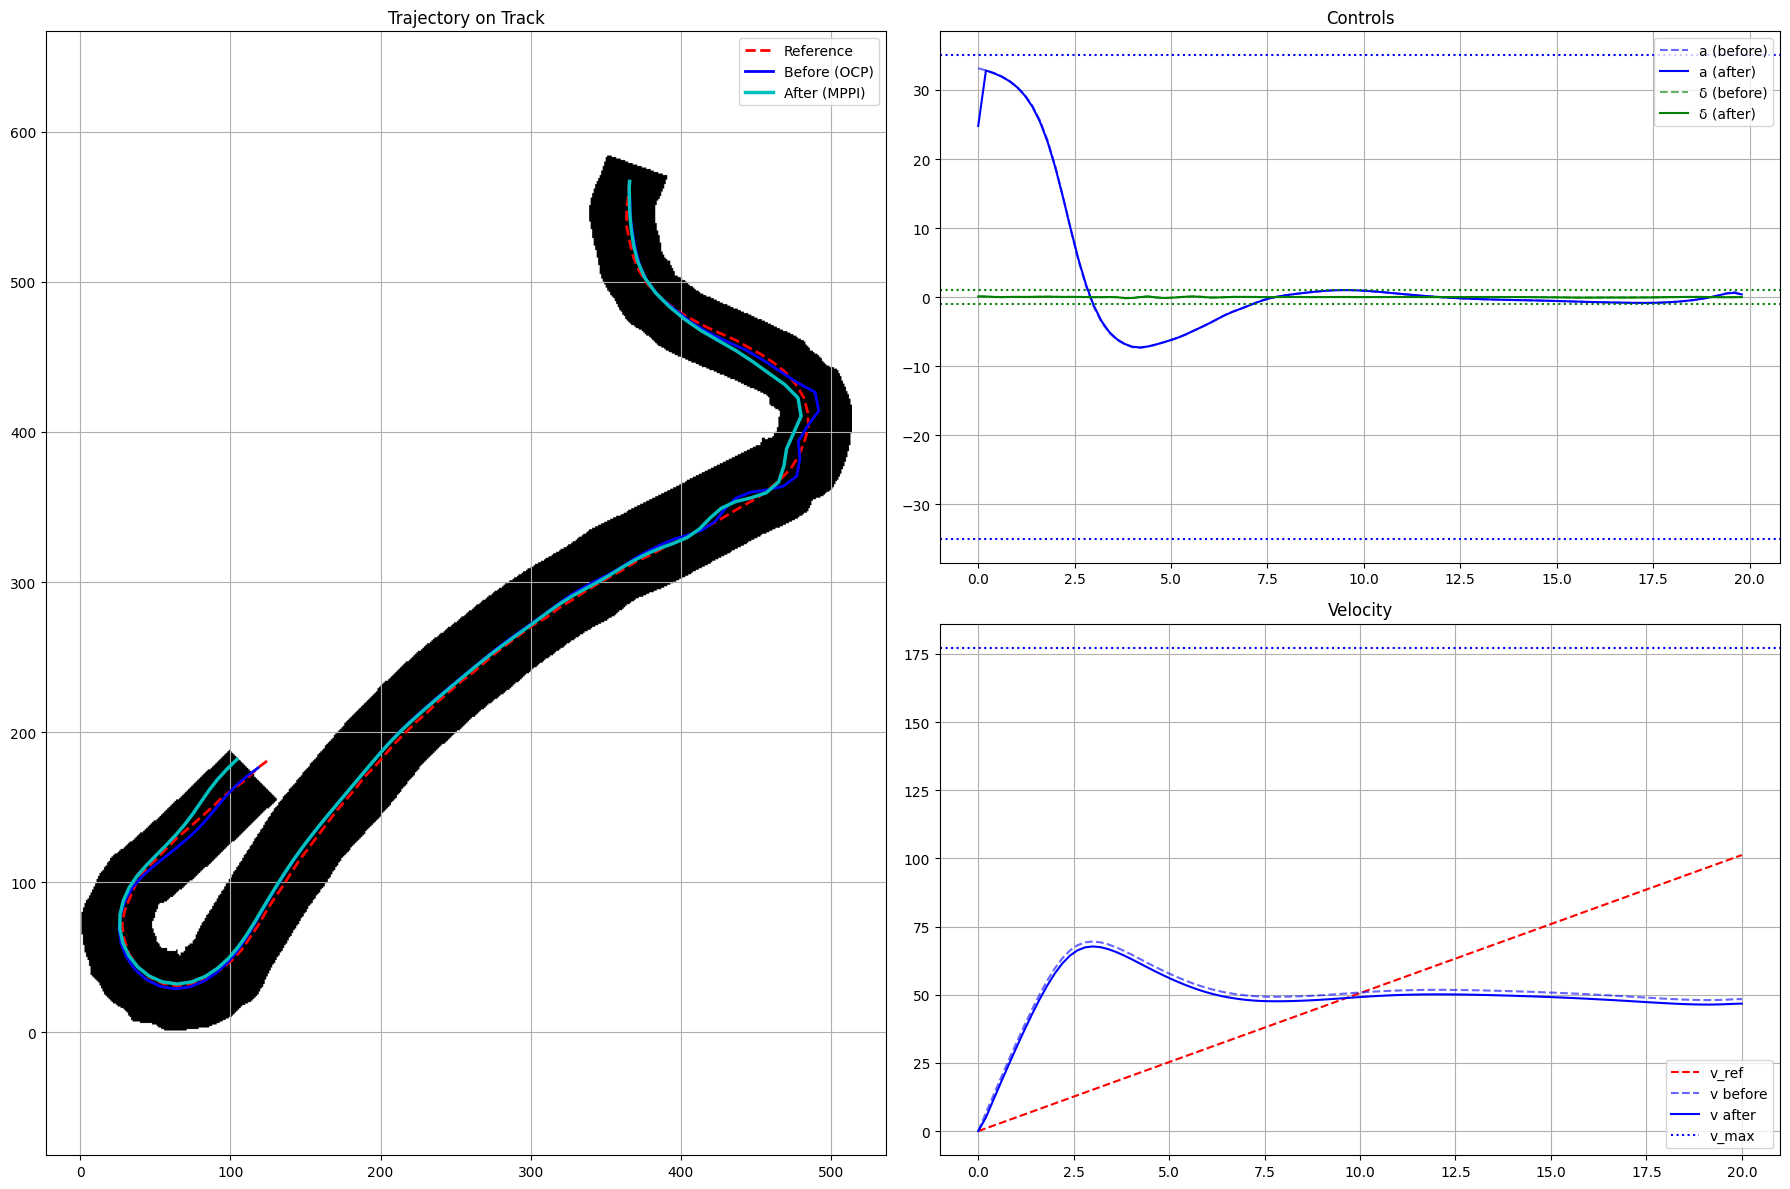

In [9]:
# ===================== MPPI (local refine, OCP-aligned) =====================
import numpy as np
import matplotlib.pyplot as plt

# ---- helpers ----
def atanh_clip(x, eps=1e-6):
    x = np.clip(x, -1+eps, 1-eps)
    return np.arctanh(x)

def lowpass_controls(u, passes=2):
    if passes <= 0: return u
    k = np.array([1.0, 2.0, 1.0]) / 4.0
    out = u.copy()
    for _ in range(passes):
        for j in range(2):
            out[:, j] = np.convolve(out[:, j], k, mode='same')
    return out

# ---- OCP-aligned cost (与上面的 OCP 保持一致 + 轻量速度/进度项) ----
def rollout_cost_ocp_aligned(states, u_seq, raceline_ref, theta_ref, v_ref,
                             # 与 OCP 同步的权重
                             w_path=5.0, w_u=1e-3, w_smooth=0.05,
                             w_v=0.12, w_terminal=30.0,
                             # inverse-barrier 安全项
                             sdf_map=None, safety_margin_pix=10.0, w_safety=1.5e4,
                             # 轻量“别停”与“往前走”引导（可按需微调/关掉）
                             v_min_factor=0.35, w_vmin=0.08, w_prog=120.0):
    # 1) 路径
    pos_err = states[:, :2] - raceline_ref
    J_path = np.sum(np.einsum('ij,ij->i', pos_err, pos_err))
    # 2) 控制能量与平滑
    J_u = np.sum(u_seq**2)
    J_smooth = np.sum(np.diff(u_seq, axis=0)**2)
    # 3) 速度
    J_v = np.sum((states[:, 3] - v_ref)**2)
    # 4) 末端
    term_pos = np.sum((states[-1, :2] - raceline_ref[-1])**2)
    dtheta = (states[-1, 2] - theta_ref[-1] + np.pi) % (2*np.pi) - np.pi
    J_term = term_pos + 0.1 * dtheta**2
    # 5) inverse-barrier 安全
    J_safe = 0.0
    if sdf_map is not None:
        sdf_vals = sample_sdf_bilinear(sdf_map, states[:, :2])
        clear = sdf_vals - safety_margin_pix
        phi = 1.0 / np.maximum(clear, 1.0)**2
        J_safe = np.sum(phi)
    # 6) 速度下限（防止停车取巧）
    v_min = v_min_factor * avg_speed_pixels
    J_vmin = np.sum(np.maximum(0.0, v_min - states[:, 3])**2)
    # 7) 进度（末端离终点的弧长差）
    idx = np.argmin(np.sum((raceline_ref - states[-1, :2])**2, axis=1))
    J_prog = (len(raceline_ref) - 1 - idx)**2

    J = (w_path*J_path + w_u*J_u + w_smooth*J_smooth +
         w_v*J_v + w_terminal*J_term + w_safety*J_safe +
         w_vmin*J_vmin + w_prog*J_prog)
    return float(J)

# ---- MPPI（小信赖域，本地微调；只采样动作） ----
def mppi_local_refine(u_base, x0,
                      iters=25, N=2048,
                      # 采样在 z-space，保持在 tanh 的线性区
                      sigma_z_a=0.18, sigma_z_delta=0.10,
                      # 时间相关噪声（温和）
                      rho=0.85,
                      # 信赖域：相对基准 z 的最大偏移 & 每次步长裁剪
                      z_tr_clip=0.35, z_step_clip=0.20,
                      # MPPI 温度 & 步长
                      lam=3000.0, step_size=0.9,
                      # 平滑与盒约束
                      smooth_passes=2,
                      # 动力学（与 OCP 对齐）
                      L_pix=None, v_max=None, delta_rate_max=2.5,
                      # 代价参数
                      cost_kwargs=None):
    assert u_base.ndim == 2 and u_base.shape[1] == 2
    T = u_base.shape[0]
    if L_pix is None: L_pix = 2.7 * resolution

    # 基准 z（tanh 逆）
    z0 = np.zeros_like(u_base)
    z0[:, 0] = atanh_clip(u_base[:, 0] / a_max)
    z0[:, 1] = atanh_clip(u_base[:, 1] / delta_max)

    # 当前均值 = 基准
    z_mean = z0.copy()

    # 评估基线
    states_best = simulate_vehicle_bc(x0, u_base, dt, T+1, L_pix=L_pix, v_max=v_max, delta_rate_max=delta_rate_max)
    J_best = rollout_cost_ocp_aligned(states_best, u_base, raceline_ref, theta_ref, v_ref,
                                      sdf_map=sdf_map, safety_margin_pix=safety_margin_pix, **(cost_kwargs or {}))
    u_best = u_base.copy()

    for it in range(iters):
        # 生成时间相关噪声（独立 2 维）
        eps = np.random.randn(N, T, 2)
        for k in range(1, T):
            eps[:, k, :] = rho * eps[:, k-1, :] + np.sqrt(1-rho**2) * eps[:, k, :]
        eps[:, :, 0] *= sigma_z_a
        eps[:, :, 1] *= sigma_z_delta

        # z-samples + 信赖域约束
        z_samp = z_mean[None, :, :] + eps
        z_samp = z0[None, :, :] + np.clip(z_samp - z0[None, :, :], -z_tr_clip, z_tr_clip)

        # 映射到动作、平滑、裁到盒
        u_samp = np.empty_like(z_samp)
        u_samp[:, :, 0] = a_max   * np.tanh(z_samp[:, :, 0])
        u_samp[:, :, 1] = delta_max * np.tanh(z_samp[:, :, 1])
        if smooth_passes > 0:
            for i in range(N):
                u_samp[i] = lowpass_controls(u_samp[i], passes=smooth_passes)
        u_samp[:, :, 0] = np.clip(u_samp[:, :, 0], -a_max, a_max)
        u_samp[:, :, 1] = np.clip(u_samp[:, :, 1], -delta_max, delta_max)

        # 评估
        costs = np.empty(N, dtype=np.float64)
        for i in range(N):
            states_i = simulate_vehicle_bc(x0, u_samp[i], dt, T+1, L_pix=L_pix, v_max=v_max, delta_rate_max=delta_rate_max)
            costs[i] = rollout_cost_ocp_aligned(
                states_i, u_samp[i], raceline_ref, theta_ref, v_ref,
                sdf_map=sdf_map, safety_margin_pix=safety_margin_pix, **(cost_kwargs or {})
            )

        # MPPI 权重
        Jmin = np.min(costs)
        w = np.exp(-(costs - Jmin) / lam)
        S = np.sum(w) + 1e-12

        # 加权更新（限制步长）
        dz = (w[:, None, None] * (z_samp - z_mean[None, :, :])).sum(axis=0) / S
        dz = np.clip(dz, -z_step_clip, +z_step_clip)
        z_mean = z_mean + step_size * dz
        # 继续施加信赖域
        z_mean = z0 + np.clip(z_mean - z0, -z_tr_clip, z_tr_clip)

        # 记录最好
        i_best = np.argmin(costs)
        if costs[i_best] < J_best:
            J_best = float(costs[i_best])
            u_best = u_samp[i_best].copy()
            states_best = simulate_vehicle_bc(x0, u_best, dt, T+1, L_pix=L_pix, v_max=v_max, delta_rate_max=delta_rate_max)

        # 自适应降噪：若改进慢，缩小方差
        if (it+1) % 6 == 0:
            sigma_z_a *= 0.85
            sigma_z_delta *= 0.85

        if (it+1) % 5 == 0:
            print(f"[MPPI] iter {it+1:02d}/{iters}  J_best={J_best:.3e}  sig=({sigma_z_a:.3f},{sigma_z_delta:.3f})")

    # 输出：再做一次平滑与盒约束
    u_best = lowpass_controls(u_best, passes=1)
    u_best[:, 0] = np.clip(u_best[:, 0], -a_max, a_max)
    u_best[:, 1] = np.clip(u_best[:, 1], -delta_max, delta_max)
    states_best = simulate_vehicle_bc(x0, u_best, dt, T+1, L_pix=L_pix, v_max=v_max, delta_rate_max=delta_rate_max)
    return u_best, states_best, J_best

print("Polishing with MPPI (local refine, OCP-aligned)...")
u_mppi, states_mppi, J_mppi = mppi_local_refine(
    u_optimal, x0,
    iters=30, N=2048,
    sigma_z_a=0.18, sigma_z_delta=0.10,
    rho=0.85, z_tr_clip=0.35, z_step_clip=0.20,
    lam=3000.0, step_size=0.9,
    smooth_passes=2,
    L_pix=2.7*resolution, v_max=v_max, delta_rate_max=2.5,   # 与 OCP 对齐！
    cost_kwargs=dict(  # 适度提高速度与进度比重，防止“停车取巧”
        w_v=0.12, w_safety=1.5e4, v_min_factor=0.35, w_vmin=0.08, w_prog=120.0
    )
)

# 诊断对比
pre_clear  = sample_sdf_bilinear(sdf_map, states_optimal[:, :2]) - safety_margin_pix
post_clear = sample_sdf_bilinear(sdf_map, states_mppi[:, :2])    - safety_margin_pix
print(f"MPPI best J  : {J_mppi:.3e}")
print(f"Min clearance before: {np.min(pre_clear):.2f} px | after: {np.min(post_clear):.2f} px")

# 简单对比可视化
def plot_mppi_results(states_pre, u_pre, states_post, u_post,
                      raceline_ref, v_ref, grid_map, dt, a_max, delta_max, v_max):
    t_s = np.arange(states_post.shape[0]) * dt
    t_u = np.arange(u_post.shape[0]) * dt

    fig = plt.figure(figsize=(18, 12))
    gs = fig.add_gridspec(2, 2)

    ax1 = fig.add_subplot(gs[:, 0])
    ax1.imshow(grid_map, cmap='gray', origin='lower',
               extent=[0, grid_map.shape[1], 0, grid_map.shape[0]])
    ax1.plot(raceline_ref[:,0], raceline_ref[:,1], 'r--', lw=2, label='Reference')
    ax1.plot(states_pre[:,0],  states_pre[:,1],  'b-', lw=2.0, label='Before (OCP)')
    ax1.plot(states_post[:,0], states_post[:,1], 'c-', lw=2.5, label='After (MPPI)')
    ax1.axis('equal'); ax1.grid(True); ax1.legend(); ax1.set_title('Trajectory on Track')

    ax2 = fig.add_subplot(gs[0, 1])
    ax2.plot(t_u, u_pre[:,0],  'b--', alpha=0.6, label='a (before)')
    ax2.plot(t_u, u_post[:,0], 'b-',  label='a (after)')
    ax2.axhline(a_max, color='b', ls=':'); ax2.axhline(-a_max, color='b', ls=':')
    ax2.plot(t_u, u_pre[:,1],  'g--', alpha=0.6, label='δ (before)')
    ax2.plot(t_u, u_post[:,1], 'g-',  label='δ (after)')
    ax2.axhline(delta_max, color='g', ls=':'); ax2.axhline(-delta_max, color='g', ls=':')
    ax2.grid(True); ax2.legend(); ax2.set_title('Controls')

    ax3 = fig.add_subplot(gs[1, 1])
    ax3.plot(t_s, v_ref, 'r--', label='v_ref')
    ax3.plot(t_s, states_pre[:,3],  'b--', alpha=0.6, label='v before')
    ax3.plot(t_s, states_post[:,3], 'b-',  label='v after')
    ax3.axhline(v_max, color='b', ls=':', label='v_max')
    ax3.grid(True); ax3.legend(); ax3.set_title('Velocity')

    plt.tight_layout(); plt.show()

print("\n--- Plotting MPPI Results ---")
plot_mppi_results(states_optimal, u_optimal, states_mppi, u_mppi,
                  raceline_ref, v_ref, grid_map, dt, a_max, delta_max, v_max)


=== START(END in inverse mode)  ===

 A: (349.3, 572.1)
 B: (382.7, 561.9)

=== END (START in inverse mode) ===
A' (120.70, 153.80)
B' (95.90, 178.50)

[ALM] outer 1/6  mu=2.00e+03  max_viol=1.632px  J=6.731e+04
[ALM] outer 2/6  mu=8.00e+03  max_viol=1.632px  J=8.636e+04
[ALM] outer 3/6  mu=3.20e+04  max_viol=0.867px  J=9.708e+04
[ALM] outer 4/6  mu=1.28e+05  max_viol=0.867px  J=1.839e+05
[ALM] outer 5/6  mu=5.12e+05  max_viol=0.867px  J=5.314e+05
[ALM] outer 6/6  mu=2.05e+06  max_viol=0.867px  J=1.921e+06
[LOCKCHK] start_err=0.00px, end_err=3.42px  => NOT OK
[ALM] outer 1/6  mu=2.00e+03  max_viol=9.000px  J=2.278e+06
[ALM] outer 2/6  mu=8.00e+03  max_viol=9.000px  J=5.055e+06
[ALM] outer 3/6  mu=3.20e+04  max_viol=9.000px  J=1.616e+07
[ALM] outer 4/6  mu=1.28e+05  max_viol=9.000px  J=6.059e+07
[ALM] outer 5/6  mu=5.12e+05  max_viol=9.000px  J=2.383e+08
[ALM] outer 6/6  mu=2.05e+06  max_viol=9.000px  J=9.492e+08
[LOCKCHK] start_err=0.00px, end_err=20.00px  => NOT OK
[ALM] outer 1/6  mu=2.00e+03  max_viol=15.950px  J=5.510e+06
[ALM] outer 2/6  mu=8.00e+03  max_viol=15.468px  J=7.738e+06
[ALM] outer 3/6  mu=3.20e+04  max_viol=15.460px  

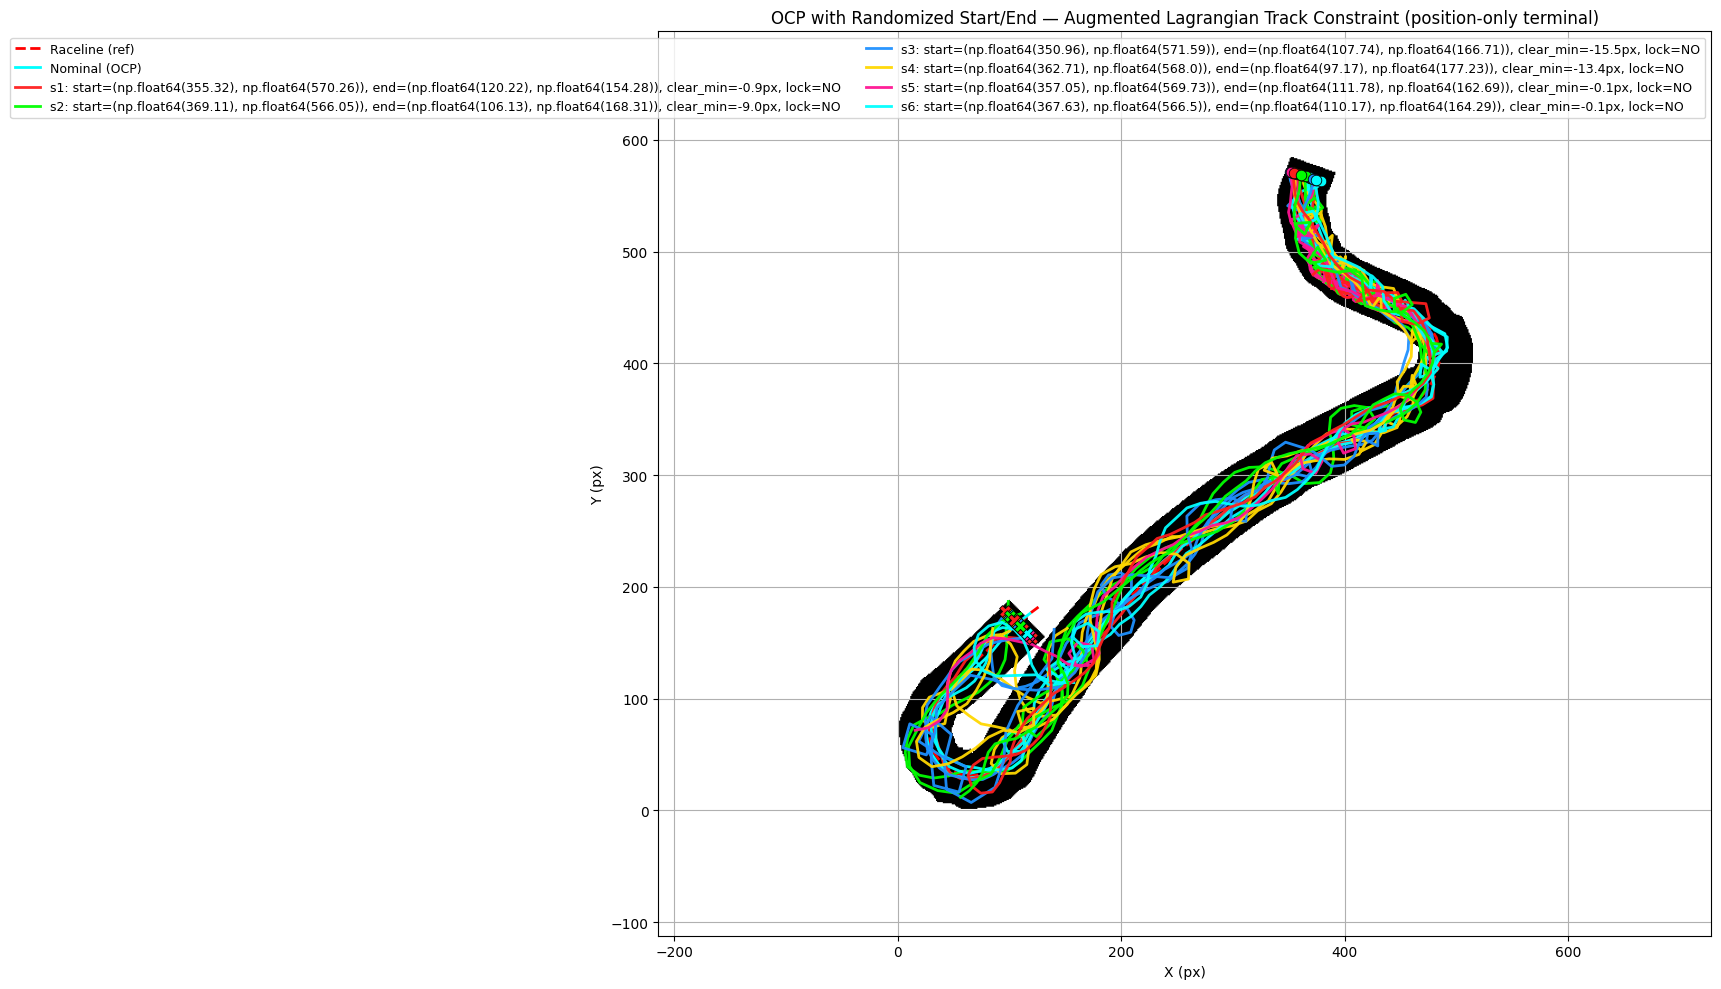

In [71]:
# ===================== OCP (position-only) with Augmented Lagrangian track constraint =====================
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colormaps as cm
from scipy.optimize import minimize
import os

SAVE_PATH = "./outputs/ocp_dataset_start_end_pos_only_ALM.npz"
os.makedirs(os.path.dirname(SAVE_PATH), exist_ok=True)

# ---- 依赖于你已有的变量/函数 ----
# simulate_vehicle_bc, unpack_controls, sample_sdf_bilinear
# grid_map, raceline_ref, theta_ref, v_ref, dt, state_steps, control_steps
# resolution, v_max, a_max, delta_max, sdf_map, safety_margin_pix
# u_optimal, states_optimal

# ---- 给定起/终点线段（像素）----
START_A = np.array([349.3, 572.1]); START_B = np.array([382.7, 561.9])
END_A   = np.array([120.70, 153.80]); END_B   = np.array([95.90, 178.50])

def rand_on_segment(A, B, t=None):
    if t is None: t = np.random.rand()
    return A + t * (B - A), float(t)

def smoothstep01(t):
    t = np.clip(t, 0.0, 1.0)
    return 3*t**2 - 2*t**3

def build_path_taper(T, start_frac=0.25, end_frac=0.25):
    """端点削弱路径项，降低对 nominal 的粘性"""
    s = np.linspace(0.0, 1.0, T)
    w_start = smoothstep01(np.clip(s/start_frac, 0, 1))
    w_end   = smoothstep01(np.clip((1-s)/end_frac, 0, 1))
    return np.minimum(w_start, w_end)

# ------------------- Augmented Lagrangian 代价 -------------------
def ocp_cost_pos_only_ALM(z_flat, x0, raceline_ref, v_ref, dt,
                          state_steps, control_steps, a_max, delta_max,
                          L_pix, v_max, sdf_map,
                          # 终端（仅位置）
                          end_goal_pos,
                          # 经典权重
                          w_path, w_u, w_smooth, w_v, w_terminal, w_funnel, end_funnel_frac,
                          path_taper_vec,
                          # ALM 参数
                          lam_vec, mu, safety_margin_pix,
                          # 可选：小的内部屏障，远离边界
                          beta_intbar=0.0):
    u_seq = unpack_controls(z_flat, control_steps, a_max, delta_max)
    X = simulate_vehicle_bc(x0, u_seq, dt, state_steps, L_pix=L_pix, v_max=v_max, delta_rate_max=2.5)
    pos = X[:, :2]

    # 1) 路径（端点衰减）
    err = pos[:raceline_ref.shape[0]] - raceline_ref
    J_path = np.sum(path_taper_vec[:err.shape[0]] * np.einsum('ij,ij->i', err, err))

    # 2) 控制 & 平滑 & 速度
    J_u = np.sum(u_seq**2)
    J_smooth = np.sum(np.diff(u_seq, axis=0)**2)
    J_v = np.sum((X[:,3] - v_ref[:X.shape[0]])**2)

    # 3) 终端（仅位置软约束 + 轻 funnel）
    term_pos = np.sum((pos[-1] - end_goal_pos[:2])**2)
    J_term_soft = term_pos

    T = control_steps
    k0 = int((1.0 - end_funnel_frac) * T)
    J_funnel = 0.0
    if k0 < state_steps:
        e_end = pos[k0:] - raceline_ref[k0:]
        J_funnel = np.sum(np.einsum('ij,ij->i', e_end, e_end))

    # 4) 赛道约束：g_k(x) = safety_margin - sdf(x_k) <= 0
    sdf_vals = sample_sdf_bilinear(sdf_map, pos)
    g = safety_margin_pix - sdf_vals
    h = np.maximum(0.0, g)                          # 仅对违反的时刻惩罚
    J_AL = np.dot(lam_vec, h) + 0.5 * mu * np.sum(h*h)

    # 5) 内部屏障（可选）：让解远离边界（sdf 越小罚越大）
    J_int = 0.0
    if beta_intbar > 0.0:
        J_int = beta_intbar * np.sum(1.0 / np.maximum(sdf_vals, 1.0)**2)

    J = (w_path*J_path + w_u*J_u + w_smooth*J_smooth + w_v*J_v +
         w_terminal*J_term_soft + w_funnel*J_funnel + J_AL + J_int)
    return float(J)

# ------------------- ALM 外循环求解器 -------------------
def solve_ocp_pos_only_ALM(x0, end_goal, path_taper_vec, u_nom=None,
                           # 经典权重
                           w_path=6.0, w_u=1e-3, w_smooth=0.08, w_v=0.10,
                           w_terminal=160.0, w_funnel=6.0, end_funnel_frac=0.10,
                           # ALM 参数
                           mu0=2e3, mu_factor=4.0, mu_max=2e7, beta_intbar=200.0,
                           alm_outer=6, feas_tol=0.25,
                           # 终止条件/数值
                           L_pix=None, v_max=None):
    if L_pix is None: L_pix = 2.7 * resolution
    Tz = control_steps

    # 初始 z（nominal 轻暖启动+小扰动）
    if u_nom is not None:
        z0 = np.zeros((Tz, 2))
        z0[:,0] = np.arctanh(np.clip(u_nom[:,0]/a_max,    -0.999999, 0.999999))
        z0[:,1] = np.arctanh(np.clip(u_nom[:,1]/delta_max,-0.999999, 0.999999))
        z0 = z0.ravel()
        z0 += 0.05 * np.random.randn(z0.size)
    else:
        z0 = np.zeros(Tz*2)

    # ALM 初始化
    lam = np.zeros(state_steps)   # 每个时刻一个乘子
    mu  = float(mu0)

    res = None
    for outer in range(alm_outer):
        # 固定 (lam, mu) 做一次无约束最小化（L-BFGS-B）
        res = minimize(
            ocp_cost_pos_only_ALM, z0,
            args=(x0, raceline_ref, v_ref, dt, state_steps, control_steps,
                  a_max, delta_max, L_pix, v_max, sdf_map,
                  end_goal, w_path, w_u, w_smooth, w_v, w_terminal, w_funnel, end_funnel_frac,
                  path_taper_vec, lam, mu, safety_margin_pix, beta_intbar),
            method="L-BFGS-B",
            options={"maxiter": 400, "maxfun": 200000, "ftol": 1e-6, "gtol": 1e-5, "maxls": 50, "disp": False}
        )
        z0 = res.x

        # 评估违反程度并更新乘子
        u_tmp = unpack_controls(res.x, control_steps, a_max, delta_max)
        X_tmp = simulate_vehicle_bc(x0, u_tmp, dt, state_steps, L_pix=L_pix, v_max=v_max, delta_rate_max=2.5)
        sdf_vals = sample_sdf_bilinear(sdf_map, X_tmp[:, :2])
        g = safety_margin_pix - sdf_vals
        h = np.maximum(0.0, g)
        max_viol = float(np.max(h))
        print(f"[ALM] outer {outer+1}/{alm_outer}  mu={mu:.2e}  max_viol={max_viol:.3f}px  J={float(res.fun):.3e}")

        # 满足可行性就退出
        if max_viol <= feas_tol:
            break

        # 乘子与惩罚更新（标准 ALM）
        lam = lam + mu * h
        mu  = min(mu * mu_factor, mu_max)

    # 返回最终解
    u_opt = unpack_controls(res.x, control_steps, a_max, delta_max)
    X_opt = simulate_vehicle_bc(x0, u_opt, dt, state_steps, L_pix=L_pix, v_max=v_max, delta_rate_max=2.5)
    return u_opt, X_opt, float(res.fun)

# ------------------- 端点一致性（仅位置） -------------------
def monitor_lock_pos_only(X, x0_target, end_goal, pos_tol=1.5, verbose=True):
    start_err = float(np.linalg.norm(X[0,:2]  - x0_target[:2]))
    end_err   = float(np.linalg.norm(X[-1,:2] - end_goal[:2]))
    ok = (start_err <= pos_tol) and (end_err <= pos_tol)
    if verbose:
        print(f"[LOCKCHK] start_err={start_err:.2f}px, end_err={end_err:.2f}px  => {'OK' if ok else 'NOT OK'}")
    return dict(ok=ok, start_err=start_err, end_err=end_err)

# ===================== 数据集生成 =====================
np.random.seed(11)

NUM_SAMPLES = 20
traj_states = np.zeros((NUM_SAMPLES, state_steps, 4))
traj_ctrls  = np.zeros((NUM_SAMPLES, control_steps, 2))
meta        = []

path_taper_vec = build_path_taper(state_steps, start_frac=0.25, end_frac=0.25)

for i in range(NUM_SAMPLES):
    # 线段上随机起终点
    start_xy, t_s = rand_on_segment(START_A, START_B)
    end_xy,   t_e = rand_on_segment(END_A, END_B)

    # 起点朝向：用 raceline 最近切向
    d = np.sum((raceline_ref - start_xy[None,:])**2, axis=1)
    idx = int(np.argmin(d)); idx2 = min(idx+1, len(raceline_ref)-1)
    theta0 = np.arctan2(raceline_ref[idx2,1]-raceline_ref[idx,1],
                        raceline_ref[idx2,0]-raceline_ref[idx,0])

    x0 = np.array([start_xy[0], start_xy[1], theta0, 0.0])
    end_goal = np.array([end_xy[0], end_xy[1]])

    # ALM 求解（nominal 仅作轻暖启动）
    u_i, X_i, J_i = solve_ocp_pos_only_ALM(
        x0, end_goal, path_taper_vec,
        u_nom=u_optimal,
        w_path=6.0, w_u=1e-3, w_smooth=0.08, w_v=0.10, w_terminal=160.0,
        w_funnel=6.0, end_funnel_frac=0.10,
        mu0=2e3, mu_factor=4.0, mu_max=2e7, beta_intbar=200.0,
        alm_outer=6, feas_tol=0.3,
        L_pix=2.7*resolution, v_max=v_max
    )

    mon = monitor_lock_pos_only(X_i, x0, end_goal, pos_tol=1.5, verbose=True)

    # 记录
    traj_states[i] = X_i
    traj_ctrls[i]  = u_i
    # 统计最小净空
    sdf_vals = sample_sdf_bilinear(sdf_map, X_i[:, :2])
    min_clear = float(np.min(sdf_vals - safety_margin_pix))
    meta.append(dict(J=float(J_i),
                     start_xy=tuple(np.round(start_xy,2)), end_xy=tuple(np.round(end_xy,2)),
                     t_s=float(t_s), t_e=float(t_e),
                     start_err=float(mon['start_err']), end_err=float(mon['end_err']),
                     lock_ok=bool(mon['ok']), min_clear=min_clear))

# 保存
np.savez(SAVE_PATH,
         traj_states=traj_states,
         traj_ctrls=traj_ctrls,
         raceline_ref=raceline_ref,
         theta_ref=theta_ref,
         v_ref=v_ref,
         safety_margin_pix=safety_margin_pix,
         start_seg=(START_A, START_B),
         end_seg=(END_A, END_B),
         meta=np.array(meta, dtype=object))
print(f"Saved to {SAVE_PATH}")

# 可视化
bright_colors = ['#FF1E1E', '#00FF00', '#1E90FF', '#FFD700', '#FF1493', '#00FFFF']  # 明亮的颜色列表
plt.figure(figsize=(16,10))
plt.imshow(grid_map, cmap='gray', origin='lower',
           extent=[0, grid_map.shape[1], 0, grid_map.shape[0]])
plt.plot(raceline_ref[:,0], raceline_ref[:,1], 'r--', lw=2, label='Raceline (ref)')
plt.plot(states_optimal[:,0], states_optimal[:,1], color='#00FFFF', lw=2.0, label='Nominal (OCP)')

for i in range(NUM_SAMPLES):
    c = bright_colors[i % len(bright_colors)]; Xi = traj_states[i]
    plt.plot(Xi[:,0], Xi[:,1], color=c, lw=2.0, alpha=0.95,
             label=(f"s{i+1}: start={meta[i]['start_xy']}, end={meta[i]['end_xy']}, "
                    f"clear_min={meta[i]['min_clear']:.1f}px, lock={'OK' if meta[i]['lock_ok'] else 'NO'}") if i<6 else None)
    sx, sy = meta[i]['start_xy']; ex, ey = meta[i]['end_xy']
    plt.scatter([sx], [sy], marker='o', s=58, color=c, edgecolors='k', linewidths=0.6, zorder=6)
    plt.scatter([ex], [ey], marker='X', s=72, color=c, edgecolors='k', linewidths=0.6, zorder=6)

plt.legend(ncol=2, fontsize=9)
plt.title('OCP with Randomized Start/End — Augmented Lagrangian Track Constraint (position-only terminal)')
plt.xlabel('X (px)'); plt.ylabel('Y (px)')
plt.axis('equal'); plt.grid(True); plt.tight_layout(); plt.show()


[ALM] outer 1/6  mu=2.00e+03  max_viol=1.379px  J=1.234e+05
[ALM] outer 2/6  mu=8.00e+03  max_viol=1.379px  J=1.430e+05
[ALM] outer 3/6  mu=3.20e+04  max_viol=1.379px  J=2.216e+05
[ALM] outer 4/6  mu=1.28e+05  max_viol=1.379px  J=5.359e+05
[ALM] outer 5/6  mu=5.12e+05  max_viol=1.379px  J=1.793e+06
[ALM] outer 6/6  mu=2.05e+06  max_viol=1.379px  J=6.822e+06
[RESAMPLE] discard due to segmentwise safety; resampling this item.
[ALM] outer 1/6  mu=2.00e+03  max_viol=12.667px  J=2.282e+06
[ALM] outer 2/6  mu=8.00e+03  max_viol=12.667px  J=4.607e+06
[ALM] outer 3/6  mu=3.20e+04  max_viol=12.667px  J=1.391e+07
[ALM] outer 4/6  mu=1.28e+05  max_viol=12.667px  J=5.110e+07
[ALM] outer 5/6  mu=5.12e+05  max_viol=12.667px  J=1.999e+08
[ALM] outer 6/6  mu=2.05e+06  max_viol=12.667px  J=7.951e+08
[RESAMPLE] discard due to segmentwise safety; resampling this item.
[ALM] outer 1/6  mu=2.00e+03  max_viol=12.835px  J=7.496e+07
[ALM] outer 2/6  mu=8.00e+03  max_viol=4.945px  J=7.655e+07
[ALM] outer 3/6  

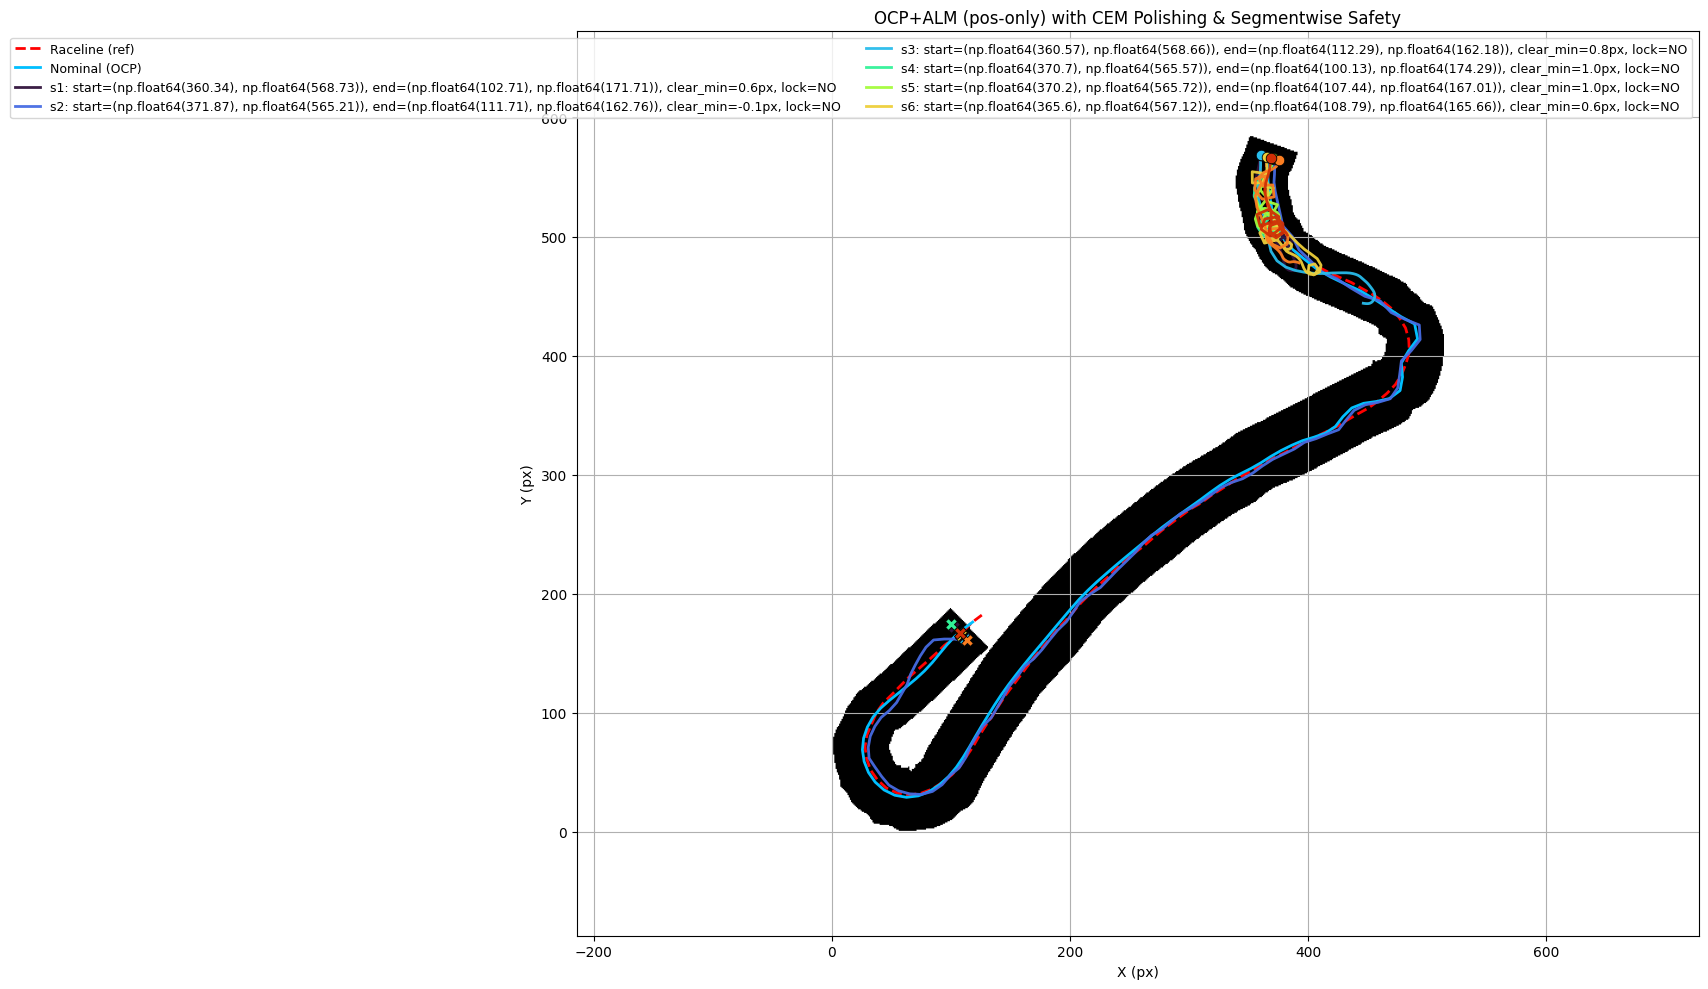

In [75]:
# ===================== OCP (position-only) + ALM Safety + CEM Polish + Segment-wise Safety =====================
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colormaps as cm
from scipy.optimize import minimize
import os

SAVE_PATH = "./outputs/ocp_dataset_start_end_pos_only_ALM_CEM.npz"
os.makedirs(os.path.dirname(SAVE_PATH), exist_ok=True)

# ---- 已存在的依赖（来自你前文）----
# simulate_vehicle_bc, unpack_controls, sample_sdf_bilinear
# grid_map, raceline_ref, theta_ref, v_ref, dt, state_steps, control_steps
# resolution, v_max, a_max, delta_max, sdf_map, safety_margin_pix
# u_optimal, states_optimal

# ---- 起/终点线段（像素; 可按需修改/已校准）----
START_A = np.array([349.3, 572.1]); START_B = np.array([382.7, 561.9])
END_A   = np.array([120.70, 153.80]); END_B   = np.array([95.90, 178.50])

# ------------------- 小工具 -------------------
def rand_on_segment(A, B, t=None):
    if t is None: t = np.random.rand()
    return A + t * (B - A), float(t)

def smoothstep01(t):
    t = np.clip(t, 0.0, 1.0)
    return 3*t**2 - 2*t**3

def build_path_taper(T, start_frac=0.25, end_frac=0.25):
    s = np.linspace(0.0, 1.0, T)
    w_start = smoothstep01(np.clip(s/start_frac, 0, 1))
    w_end   = smoothstep01(np.clip((1-s)/end_frac, 0, 1))
    return np.minimum(w_start, w_end)

def lowpass_controls(u, passes=1):
    if passes <= 0: return u
    k = np.array([1.0, 2.0, 1.0]) / 4.0
    out = u.copy()
    for _ in range(passes):
        for j in range(u.shape[1]):
            out[:, j] = np.convolve(out[:, j], k, mode='same')
    return out

def clip_u(u):
    out = u.copy()
    out[:,0] = np.clip(out[:,0], -a_max, a_max)
    out[:,1] = np.clip(out[:,1], -delta_max, delta_max)
    return out

# ------------------- 1) OCP 代价（更强平滑/能量项） -------------------
def ocp_cost_pos_only_ALM(z_flat, x0, raceline_ref, v_ref, dt,
                          state_steps, control_steps, a_max, delta_max,
                          L_pix, v_max, sdf_map,
                          # 终端（仅位置）
                          end_goal_pos,
                          # 经典权重
                          w_path, w_u, w_smooth, w_v, w_terminal, w_funnel, end_funnel_frac,
                          # 新增：转向速率和加速度变化惩罚
                          w_delta_rate, w_a_rate,
                          path_taper_vec,
                          # ALM 参数
                          lam_vec, mu, safety_margin_pix,
                          # 可选：小的内部屏障，远离边界
                          beta_intbar=0.0):
    u_seq = unpack_controls(z_flat, control_steps, a_max, delta_max)
    X = simulate_vehicle_bc(x0, u_seq, dt, state_steps, L_pix=L_pix, v_max=v_max, delta_rate_max=2.5)
    pos = X[:, :2]

    # 路径（端点衰减）
    err = pos[:raceline_ref.shape[0]] - raceline_ref
    J_path = np.sum(path_taper_vec[:err.shape[0]] * np.einsum('ij,ij->i', err, err))

    # 控制能量 / 一阶平滑（对 a, delta）
    J_u = np.sum(u_seq**2)
    du = np.diff(u_seq, axis=0)
    J_smooth = np.sum(du**2)

    # 新增：分别加强“转向速率”和“加速度变化”约束（可单独调）
    d_delta = np.diff(u_seq[:,1])
    d_a     = np.diff(u_seq[:,0])
    J_delta_rate = np.sum(d_delta**2)
    J_a_rate     = np.sum(d_a**2)

    # 速度跟踪（弱）
    J_v = np.sum((X[:,3] - v_ref[:X.shape[0]])**2)

    # 终端（仅位置软约束 + 轻 funnel）
    term_pos = np.sum((pos[-1] - end_goal_pos[:2])**2)
    J_term_soft = term_pos
    T = control_steps
    k0 = int((1.0 - end_funnel_frac) * T)
    J_funnel = 0.0
    if k0 < state_steps:
        e_end = pos[k0:] - raceline_ref[k0:]
        J_funnel = np.sum(np.einsum('ij,ij->i', e_end, e_end))

    # ALM：赛道约束
    sdf_vals = sample_sdf_bilinear(sdf_map, pos)
    g = safety_margin_pix - sdf_vals
    h = np.maximum(0.0, g)
    J_AL = np.dot(lam_vec, h) + 0.5 * mu * np.sum(h*h)

    # 小的内部屏障（可选）
    J_int = 0.0
    if beta_intbar > 0.0:
        J_int = beta_intbar * np.sum(1.0 / np.maximum(sdf_vals, 1.0)**2)

    J = (w_path*J_path + w_u*J_u + w_smooth*J_smooth + w_v*J_v +
         w_terminal*J_term_soft + w_funnel*J_funnel +
         w_delta_rate*J_delta_rate + w_a_rate*J_a_rate +
         J_AL + J_int)
    return float(J)

# ------------------- ALM 外循环求解器 -------------------
def solve_ocp_pos_only_ALM(x0, end_goal, path_taper_vec, u_nom=None,
                           # 基本权重
                           w_path=5.0, w_u=2e-3, w_smooth=0.12, w_v=0.08,
                           w_terminal=160.0, w_funnel=4.0, end_funnel_frac=0.10,
                           # 新增的平滑权重
                           w_delta_rate=0.8, w_a_rate=0.15,
                           # ALM 参数
                           mu0=2e3, mu_factor=4.0, mu_max=2e7, beta_intbar=150.0,
                           alm_outer=6, feas_tol=0.25,
                           # 数值
                           L_pix=None, v_max=None):
    if L_pix is None: L_pix = 2.7 * resolution
    Tz = control_steps

    # 初始 z（nominal 轻暖启动+小扰动）
    if u_nom is not None:
        z0 = np.zeros((Tz, 2))
        z0[:,0] = np.arctanh(np.clip(u_nom[:,0]/a_max,    -0.999999, 0.999999))
        z0[:,1] = np.arctanh(np.clip(u_nom[:,1]/delta_max,-0.999999, 0.999999))
        z0 = z0.ravel()
        z0 += 0.05 * np.random.randn(z0.size)
    else:
        z0 = np.zeros(Tz*2)

    lam = np.zeros(state_steps)
    mu  = float(mu0)
    res = None

    for outer in range(alm_outer):
        res = minimize(
            ocp_cost_pos_only_ALM, z0,
            args=(x0, raceline_ref, v_ref, dt, state_steps, control_steps,
                  a_max, delta_max, L_pix, v_max, sdf_map,
                  end_goal, w_path, w_u, w_smooth, w_v, w_terminal, w_funnel, end_funnel_frac,
                  w_delta_rate, w_a_rate,
                  path_taper_vec, lam, mu, safety_margin_pix, beta_intbar),
            method="L-BFGS-B",
            options={"maxiter": 400, "maxfun": 200000, "ftol": 1e-6, "gtol": 1e-5, "maxls": 50, "disp": False}
        )
        z0 = res.x

        # 评估违反程度并更新乘子
        u_tmp = unpack_controls(res.x, control_steps, a_max, delta_max)
        X_tmp = simulate_vehicle_bc(x0, u_tmp, dt, state_steps, L_pix=L_pix, v_max=v_max, delta_rate_max=2.5)
        sdf_vals = sample_sdf_bilinear(sdf_map, X_tmp[:, :2])
        h = np.maximum(0.0, safety_margin_pix - sdf_vals)
        max_viol = float(np.max(h))
        print(f"[ALM] outer {outer+1}/{alm_outer}  mu={mu:.2e}  max_viol={max_viol:.3f}px  J={float(res.fun):.3e}")
        if max_viol <= feas_tol:
            break
        lam = lam + mu * h
        mu  = min(mu * mu_factor, mu_max)

    u_opt = unpack_controls(res.x, control_steps, a_max, delta_max)
    X_opt = simulate_vehicle_bc(x0, u_opt, dt, state_steps, L_pix=L_pix, v_max=v_max, delta_rate_max=2.5)
    return u_opt, X_opt, float(res.fun)

# ------------------- 2) CEM 轨迹平滑 Polish（安全优先） -------------------
def cem_polish(u_base, x0, end_goal,
               iters=6, N=256, elite_frac=0.15,
               std_init=(0.20, 0.12),  # a、delta 残差的初始标准差（相对限幅的比例）
               trust_frac=(0.30, 0.22),
               smooth_passes=2,
               w_smooth=1.0, w_u=5e-4, w_terminal=200.0, w_path=2.0,
               L_pix=None, v_max=None, delta_rate_max=2.5):
    """
    在 u_base 周围做小幅残差搜索：更平滑、更贴近 raceline，且必须安全（点上 SDF>=margin）
    """
    if L_pix is None: L_pix = 2.7 * resolution
    T = u_base.shape[0]
    mean = np.zeros_like(u_base)  # 残差均值
    std  = np.column_stack([np.full(T, std_init[0]*a_max),
                            np.full(T, std_init[1]*delta_max)])

    n_elite = max(2, int(N * elite_frac))
    best = dict(cost=np.inf, u=None, X=None)

    for it in range(iters):
        # 采样残差
        eps = np.random.randn(N, T, 2) * std[None,:,:]
        du  = mean[None,:,:] + eps
        du  = np.clip(du, -trust_frac[0]*a_max, trust_frac[0]*a_max)  # 对 a 的限幅（统一标量）
        du[:,:,1] = np.clip(du[:,:,1], -trust_frac[1]*delta_max, trust_frac[1]*delta_max)

        U = u_base[None,:,:] + du
        costs = np.full(N, np.inf)
        safe  = np.zeros(N, dtype=bool)

        for i in range(N):
            ui = lowpass_controls(U[i], passes=smooth_passes)
            ui = clip_u(ui)
            Xi = simulate_vehicle_bc(x0, ui, dt, T+1, L_pix=L_pix, v_max=v_max, delta_rate_max=delta_rate_max)
            # 点上安全
            sdf_vals = sample_sdf_bilinear(sdf_map, Xi[:, :2])
            if np.min(sdf_vals - safety_margin_pix) < 0.0:
                continue  # 不安全，直接丢弃
            # 代价：以平滑+能量+路径+终点为主
            J_s = np.sum(np.diff(ui, axis=0)**2)
            J_u = np.sum(ui**2)
            J_p = np.sum((Xi[:raceline_ref.shape[0],:2] - raceline_ref)**2)
            J_t = np.sum((Xi[-1,:2] - end_goal[:2])**2)
            costs[i] = (w_smooth*J_s + w_u*J_u + w_path*J_p + w_terminal*J_t)
            safe[i]  = True
            if costs[i] < best["cost"]:
                best = dict(cost=costs[i], u=ui, X=Xi)

        # 没有安全样本，扩大 std 再试下一轮
        if not np.any(safe):
            std *= 1.3
            continue

        # 选择精英样本更新分布
        idxs = np.argsort(costs)[:n_elite]
        elite_du = (U[idxs] - u_base[None,:,:])
        mean = np.median(elite_du, axis=0)     # 稳健些
        std  = np.std(elite_du, axis=0) + 1e-6
        # 逐步收缩
        std *= 0.7

    # 若始终没找到比 base 更好的安全解，就返回 base
    if best["u"] is None:
        best["u"] = u_base
        best["X"] = simulate_vehicle_bc(x0, u_base, dt, T+1, L_pix=L_pix, v_max=v_max, delta_rate_max=delta_rate_max)
        best["cost"] = 0.0
    return best["u"], best["X"]

# ------------------- 3) 线性插值安全检测（段内采样） -------------------
def segmentwise_safety_ok(X, sdf_map, safety_margin_pix, samples_per_seg=5):
    """
    在线性插值点上检查 SDF，保证离散点之间也安全。
    """
    P = X[:, :2]
    for i in range(P.shape[0]-1):
        p0, p1 = P[i], P[i+1]
        # 在 (0,1) 之间等间距内插
        ts = np.linspace(0.0, 1.0, samples_per_seg+2)[1:-1]
        mids = (1-ts)[:,None]*p0[None,:] + ts[:,None]*p1[None,:]
        sdf_vals = sample_sdf_bilinear(sdf_map, mids)
        if np.any(sdf_vals - safety_margin_pix < 0.0):
            return False
    return True

# ------------------- 端点一致性（仅位置） -------------------
def monitor_lock_pos_only(X, x0_target, end_goal, pos_tol=1.5, verbose=True):
    start_err = float(np.linalg.norm(X[0,:2]  - x0_target[:2]))
    end_err   = float(np.linalg.norm(X[-1,:2] - end_goal[:2]))
    ok = (start_err <= pos_tol) and (end_err <= pos_tol)
    if verbose:
        print(f"[LOCKCHK] start_err={start_err:.2f}px, end_err={end_err:.2f}px  => {'OK' if ok else 'NOT OK'}")
    return dict(ok=ok, start_err=start_err, end_err=end_err)

# ===================== 数据集生成（含 CEM polish + 段内安全） =====================
np.random.seed(11)

NUM_SAMPLES = 8
MAX_RETRIES = 10          # 若段内安全失败，重采次数上限
traj_states = np.zeros((NUM_SAMPLES, state_steps, 4))
traj_ctrls  = np.zeros((NUM_SAMPLES, control_steps, 2))
meta        = []

path_taper_vec = build_path_taper(state_steps, start_frac=0.25, end_frac=0.25)

i = 0
while i < NUM_SAMPLES:
    # 线段上随机起终点
    start_xy, t_s = rand_on_segment(START_A, START_B)
    end_xy,   t_e = rand_on_segment(END_A, END_B)

    # 起点朝向：raceline 最近切向
    d = np.sum((raceline_ref - start_xy[None,:])**2, axis=1)
    idx = int(np.argmin(d)); idx2 = min(idx+1, len(raceline_ref)-1)
    theta0 = np.arctan2(raceline_ref[idx2,1]-raceline_ref[idx,1],
                        raceline_ref[idx2,0]-raceline_ref[idx,0])

    x0 = np.array([start_xy[0], start_xy[1], theta0, 0.0])
    end_goal = np.array([end_xy[0], end_xy[1]])

    # -------- OCP + ALM 基解（已含平滑与能量抑制）--------
    u_ocp, X_ocp, J_ocp = solve_ocp_pos_only_ALM(
        x0, end_goal, path_taper_vec,
        u_nom=u_optimal,
        w_path=5.0, w_u=2e-3, w_smooth=0.12, w_v=0.08,
        w_terminal=160.0, w_funnel=4.0, end_funnel_frac=0.10,
        w_delta_rate=0.8, w_a_rate=0.15,
        mu0=2e3, mu_factor=4.0, mu_max=2e7, beta_intbar=150.0,
        alm_outer=6, feas_tol=0.3,
        L_pix=2.7*resolution, v_max=v_max
    )

    # -------- CEM Polish（更顺滑 & 点上安全）--------
    u_pol, X_pol = cem_polish(
        u_ocp, x0, end_goal,
        iters=6, N=256, elite_frac=0.15,
        std_init=(0.20, 0.12), trust_frac=(0.30, 0.22),
        smooth_passes=2,
        w_smooth=1.0, w_u=5e-4, w_terminal=200.0, w_path=2.0,
        L_pix=2.7*resolution, v_max=v_max, delta_rate_max=2.5
    )

    # -------- 线性插值安全检测 + 重采 --------
    retry = 0
    while retry < MAX_RETRIES and not segmentwise_safety_ok(X_pol, sdf_map, safety_margin_pix, samples_per_seg=5):
        # 如果段内不安全，再做一次 CEM（放大信赖域/减小 std 收缩速度）
        u_pol, X_pol = cem_polish(
            u_ocp, x0, end_goal,
            iters=6, N=320, elite_frac=0.18,
            std_init=(0.22, 0.14), trust_frac=(0.34, 0.26),
            smooth_passes=3,
            w_smooth=1.2, w_u=6e-4, w_terminal=240.0, w_path=2.2,
            L_pix=2.7*resolution, v_max=v_max, delta_rate_max=2.5
        )
        retry += 1

    # 若仍不安全，丢弃并重新采样该样本
    if retry == MAX_RETRIES or not segmentwise_safety_ok(X_pol, sdf_map, safety_margin_pix, samples_per_seg=5):
        print("[RESAMPLE] discard due to segmentwise safety; resampling this item.")
        continue

    # 端点一致性（仅位置）
    mon = monitor_lock_pos_only(X_pol, x0, end_goal, pos_tol=1.5, verbose=True)

    # 记录
    traj_states[i] = X_pol
    traj_ctrls[i]  = u_pol
    sdf_vals = sample_sdf_bilinear(sdf_map, X_pol[:, :2])
    min_clear = float(np.min(sdf_vals - safety_margin_pix))

    meta.append(dict(J=float(J_ocp),
                     start_xy=tuple(np.round(start_xy,2)), end_xy=tuple(np.round(end_xy,2)),
                     t_s=float(t_s), t_e=float(t_e),
                     start_err=float(mon['start_err']), end_err=float(mon['end_err']),
                     lock_ok=bool(mon['ok']), min_clear=min_clear))
    i += 1

# 保存
np.savez(SAVE_PATH,
         traj_states=traj_states,
         traj_ctrls=traj_ctrls,
         raceline_ref=raceline_ref,
         theta_ref=theta_ref,
         v_ref=v_ref,
         safety_margin_pix=safety_margin_pix,
         start_seg=(START_A, START_B),
         end_seg=(END_A, END_B),
         meta=np.array(meta, dtype=object))
print(f"Saved to {SAVE_PATH}")

# 可视化
cmap = cm.get_cmap('turbo')
colors = [cmap(i/NUM_SAMPLES) for i in range(NUM_SAMPLES)]
plt.figure(figsize=(16,10))
plt.imshow(grid_map, cmap='gray', origin='lower',
           extent=[0, grid_map.shape[1], 0, grid_map.shape[0]])
plt.plot(raceline_ref[:,0], raceline_ref[:,1], 'r--', lw=2, label='Raceline (ref)')
plt.plot(states_optimal[:,0], states_optimal[:,1], color='deepskyblue', lw=2.0, label='Nominal (OCP)')

for i in range(NUM_SAMPLES):
    c = colors[i]; Xi = traj_states[i]
    plt.plot(Xi[:,0], Xi[:,1], color=c, lw=2.0, alpha=0.95,
             label=(f"s{i+1}: start={meta[i]['start_xy']}, end={meta[i]['end_xy']}, "
                    f"clear_min={meta[i]['min_clear']:.1f}px, lock={'OK' if meta[i]['lock_ok'] else 'NO'}") if i<6 else None)
    sx, sy = meta[i]['start_xy']; ex, ey = meta[i]['end_xy']
    plt.scatter([sx], [sy], marker='o', s=58, color=c, edgecolors='k', linewidths=0.6, zorder=6)
    plt.scatter([ex], [ey], marker='X', s=72, color=c, edgecolors='k', linewidths=0.6, zorder=6)

plt.legend(ncol=2, fontsize=9)
plt.title('OCP+ALM (pos-only) with CEM Polishing & Segmentwise Safety')
plt.xlabel('X (px)'); plt.ylabel('Y (px)')
plt.axis('equal'); plt.grid(True); plt.tight_layout(); plt.show()
